In [30]:
pip install nltk gensim scikit-learn tensorflow

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/350.8 MB 7.7 MB/s eta 0:00:46
    --------------------------------------- 5.2/350.8 MB 14.5 MB/s eta 0:00:24
    ------------------

In [36]:
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from gensim.models import Word2Vec
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("Intent_Dataset (1).csv")

In [3]:
data.head()

,QuestionText,CognitiveLevel,Category,Intent
0,أيهما أفضل الدراسة في السابق أم في الوقت الحالي؟,تقييم,التعليم,اختيار
1,أليس القطن عماد الثروة في مصر؟,معرفة,الاقتصاد والعمل,اختيار
2,أتصعد الشمس من الشرق؟,معرفة,التعليم,اختيار
3,أتعرف البكتيريا بأنها كائنات حية دقيقة؟,معرفة,التعليم,اختيار
4,أيتكون الهواء أساساً من النيتروجين؟,معرفة,التعليم,اختيار


In [4]:
data.describe()

,QuestionText,CognitiveLevel,Category,Intent
count,5009,5009,5009,5009
unique,4645,6,17,14
top,متى تم بناء سور الصين العظيم؟,معرفة,الثقافة,معلوماتي
freq,8,2021,765,2132


In [5]:
print("Cognitive Level Categories:", len(data["CognitiveLevel"].value_counts()))
print("-"*25)
print(data["CognitiveLevel"].value_counts())

Cognitive Level Categories: 6
-------------------------
CognitiveLevel
معرفة    2021
تحليل    1293
فهم      1063
تطبيق     418
تقييم     127
تركيب      87
Name: count, dtype: int64


In [6]:
print("Category Categories:", len(data["Category"].value_counts()))
print("-"*25)
print(data["Category"].value_counts())

Category Categories: 17
-------------------------
Category
الثقافة             765
العلوم              632
التعليم             624
الصحة               552
البيئة والطاقة      508
التكنولوجيا         454
التاريخ             418
الاقتصاد والعمل     298
الجغرافيا           212
السياسة والقانون    201
الدين               114
الرياضة              67
البيولوجيا           52
الترفيه              40
السفر والسياحة       37
التطوع               26
علم الاجتماع          9
Name: count, dtype: int64


In [7]:
print("Intent Categories:", len(data["Intent"].value_counts()))
print("-"*25)
print(data["Intent"].value_counts())

Intent Categories: 14
-------------------------
Intent
معلوماتي    2132
تفسير        848
شرح          569
رأي          341
اقتراح       326
مقارنة       175
اختيار       156
حساب         124
تعريف        117
تخطيط        111
إعراب         44
ترتيب         32
استدلال       26
تنبؤ           8
Name: count, dtype: int64


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5009 entries, 0 to 5008
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   QuestionText    5009 non-null   object
 1   CognitiveLevel  5009 non-null   object
 2   Category        5009 non-null   object
 3   Intent          5009 non-null   object
dtypes: object(4)
memory usage: 156.7+ KB


In [9]:
nltk.download('stopwords')
arabic_stopwords = set(stopwords.words('arabic'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
def preprocess_text(text):
    text = ''.join(char for char in text if char.isalnum() or char.isspace())

    tokens = text.split()
    tokens = [word for word in tokens if word not in arabic_stopwords]
    
    preprocessed_text = ' '.join(tokens)
    return preprocessed_text

In [11]:
count = data["QuestionText"].value_counts()

duplicates = count[count > 1]

for i in duplicates.index:
    print(i)

duplicates.shape

متى تم بناء سور الصين العظيم؟
متى تم اكتشاف البنسلين؟
من هو مؤسس علم النفس الحديث؟
من هو مكتشف البنسلين؟
كيف يمكن تقليل استهلاك الطاقة في المنازل؟
متى بدأت الثورة الصناعية؟
علام يعتمد نجاح المشاريع الصغيرة؟
من هو مخترع الهاتف؟
من هو أول رئيس للولايات المتحدة الأمريكية؟
علل أهمية الحفاظ على التنوع البيولوجي.
كيف يمكن تحسين كفاءة الطاقة في المباني؟
كم عدد العضلات في جسم الإنسان؟
إلامَ تهدفُ في تطويرِ نفسِك؟
متى تم تأسيس الأمم المتحدة؟
فيم تكمن أهمية البحث العلمي في الجامعات؟
عدد الكواكب في النظام الشمسي.
متى تم اختراع الطباعة؟
من هو مؤسس شركة مايكروسوفت؟
من هو مكتشف قانون الجاذبية؟
أين تقع جبال الألب؟
أين تقع بحيرة بايكال؟
بم يُقاس الضغط الجوي؟
متى تم اكتشاف أمريكا؟
كم يبلغ عدد الدول الأعضاء في الأمم المتحدة؟
كم يبلغ عدد قارات العالم؟
متى تم اكتشاف الكهرباء؟
كم عدد الكواكب في النظام الشمسي؟
متى تم تأسيس منظمة الأمم المتحدة؟
احسبْ عددَ الفصولِ الدراسية.
احسبْ عددَ الأنشطةِ التي مارستَها.
ماذا يعني مصطلح "الاقتصاد الأخضر"؟
من هو مؤسس علم الجبر؟
من هو مكتشف الدورة الدموية؟
من هو مخترع المصب

(274,)

In [12]:
data.drop_duplicates(subset=["QuestionText"], keep='first', inplace=True)

In [13]:
data.shape

(4645, 4)

In [14]:
preprocessed_texts = data["QuestionText"].apply(preprocess_text)
preprocessed_texts.head()

0    أيهما أفضل الدراسة السابق الوقت الحالي
1                أليس القطن عماد الثروة مصر
2                         أتصعد الشمس الشرق
3    أتعرف البكتيريا بأنها كائنات حية دقيقة
4            أيتكون الهواء أساسا النيتروجين
Name: QuestionText, dtype: object

In [26]:
tokens = preprocessed_texts.apply(word_tokenize)
tokens.head()

0    [أيهما, أفضل, الدراسة, السابق, الوقت, الحالي]
1                 [أليس, القطن, عماد, الثروة, مصر]
2                            [أتصعد, الشمس, الشرق]
3    [أتعرف, البكتيريا, بأنها, كائنات, حية, دقيقة]
4              [أيتكون, الهواء, أساسا, النيتروجين]
Name: QuestionText, dtype: object

In [18]:
lm = Word2Vec(sentences=tokens, vector_size=100, window=5, min_count=1, workers=4)

In [21]:
def document_vector(word_list, w2v_model):
    words = [word for word in word_list if word in w2v_model.wv.key_to_index]
    if len(words) == 0:
        return np.zeros(w2v_model.vector_size)
    else:
        return np.mean(w2v_model.wv[words], axis=0)

In [25]:
X = np.array([document_vector(doc, lm) for doc in tokens])

le = LabelEncoder()
y = le.fit_transform(data["Intent"])

In [34]:
y_categorical = to_categorical(y)

In [39]:
def create_nn_model(input_dim, num_classes):
    model = Sequential()
    model.add(Dense(128, activation='relu', input_dim=input_dim))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


In [40]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
num_classes = len(np.unique(y))

all_histories = []
all_predictions = []
all_true_labels = []

c:\Users\User\anaconda3\envs\py311\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 8 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\User\anaconda3\envs\py311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Fold 1...


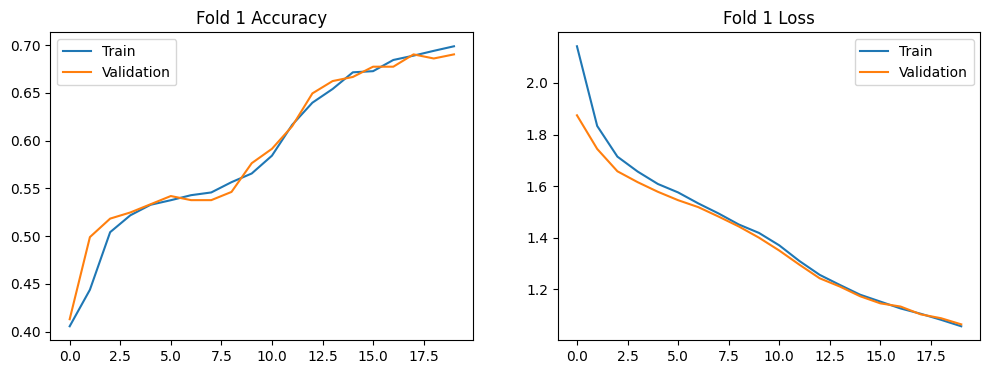

Training Fold 2...


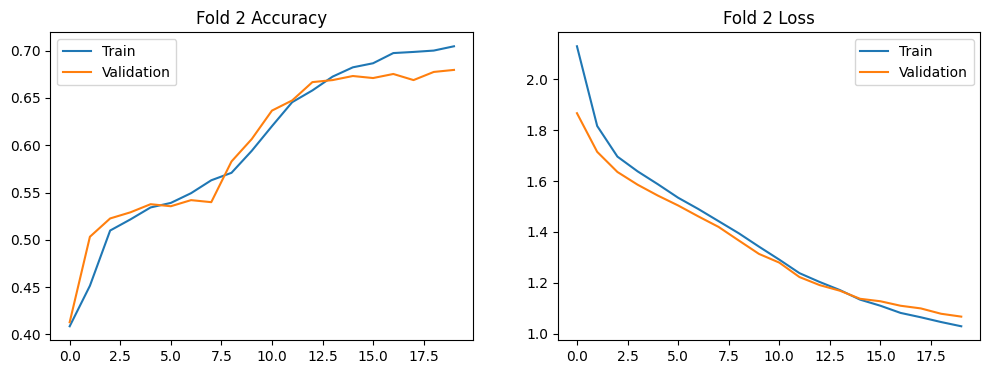

Training Fold 3...


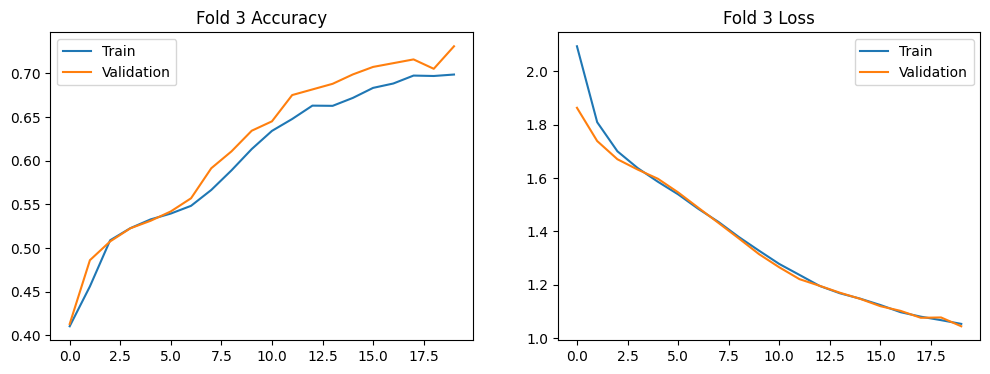

Training Fold 4...


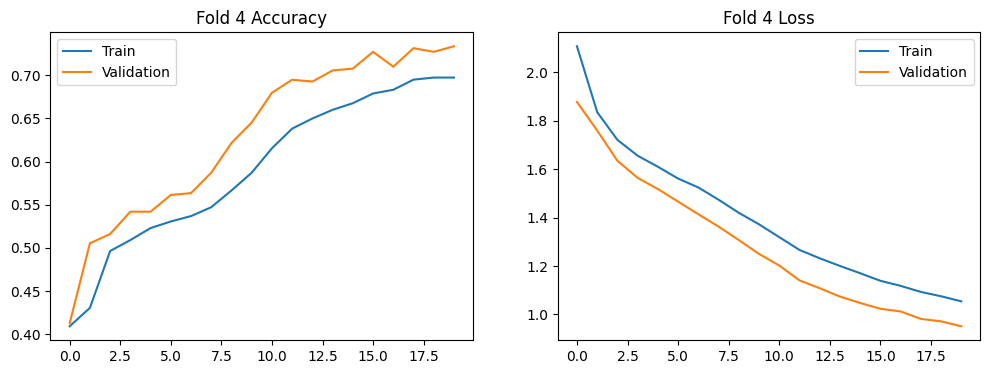

Training Fold 5...


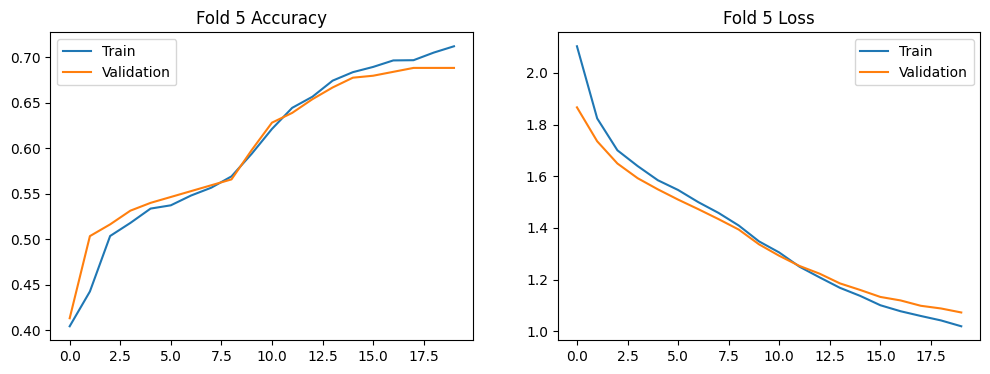

Training Fold 6...


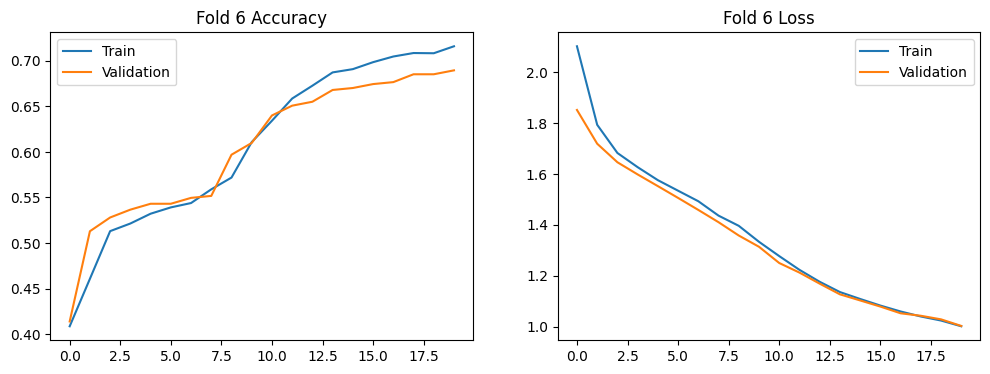

Training Fold 7...


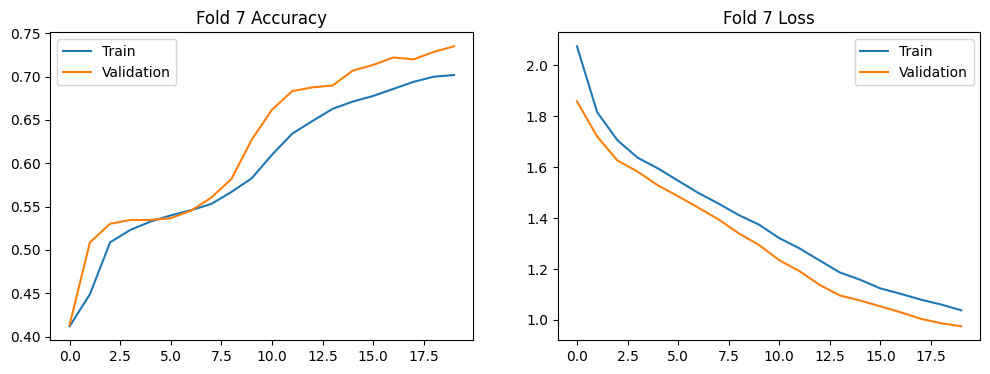

Training Fold 8...


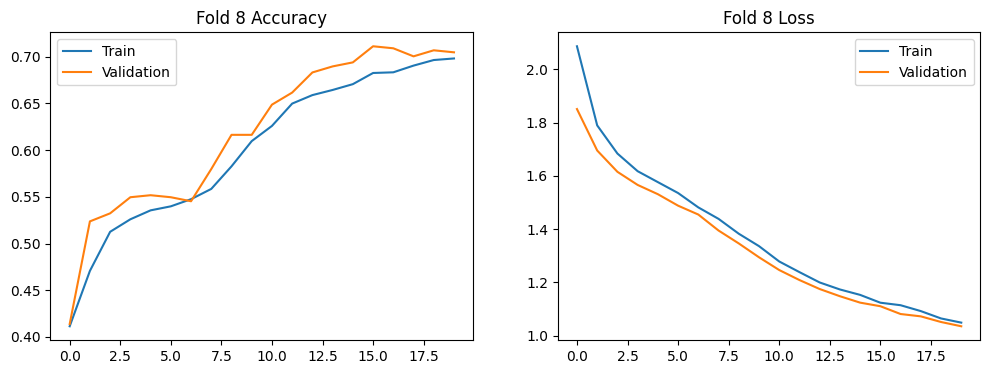

Training Fold 9...


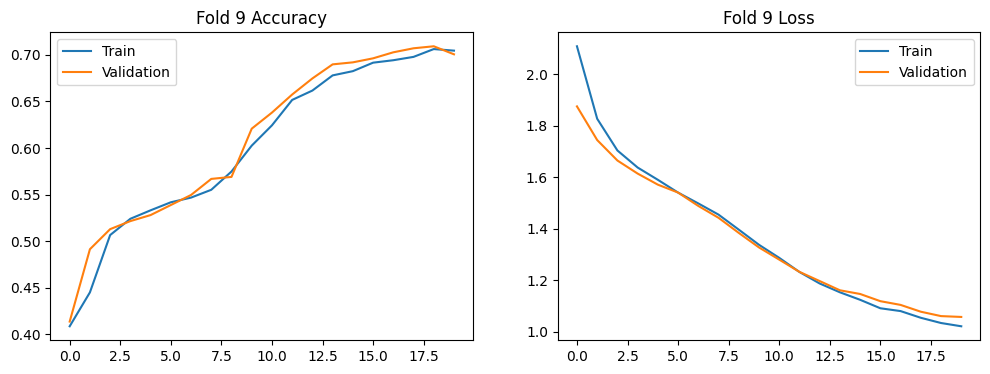

Training Fold 10...


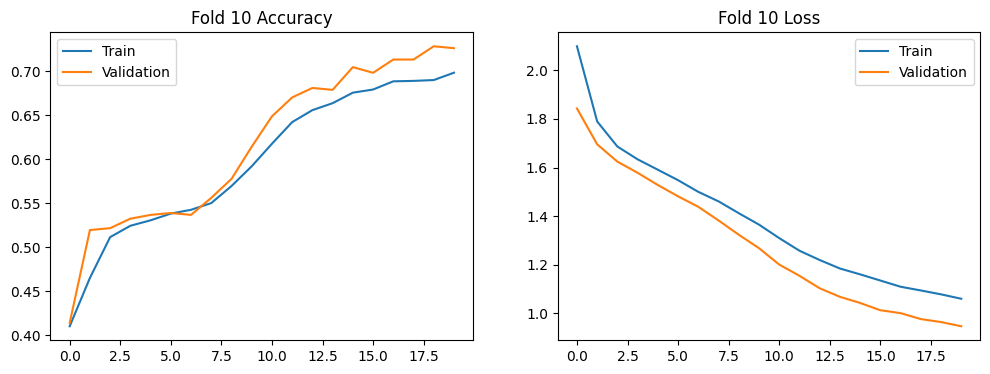

Final 10-Fold Cross Validation Report:
              precision    recall  f1-score   support

       إعراب       0.53      0.76      0.63        41
      اختيار       0.00      0.00      0.00       153
     استدلال       0.00      0.00      0.00        25
      اقتراح       0.69      0.80      0.74       310
       تخطيط       0.83      0.82      0.82        92
       ترتيب       0.00      0.00      0.00        32
       تعريف       1.00      0.03      0.05       109
       تفسير       0.88      0.86      0.87       834
        تنبؤ       0.00      0.00      0.00         8
        حساب       1.00      0.02      0.04       103
         رأي       0.81      0.42      0.55       323
         شرح       0.86      0.49      0.62       532
    معلوماتي       0.64      0.95      0.76      1920
      مقارنة       0.00      0.00      0.00       163

    accuracy                           0.71      4645
   macro avg       0.52      0.37      0.36      4645
weighted avg       0.69      0.71      0.

c:\Users\User\anaconda3\envs\py311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\envs\py311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\envs\py311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [41]:
fold_no = 1
for train, test in kfold.split(X, y):
    print(f'Training Fold {fold_no}...')
    
    model = create_nn_model(input_dim=X.shape[1], num_classes=num_classes)
    
    history = model.fit(X[train], y_categorical[train], validation_data=(X[test], y_categorical[test]), epochs=20, batch_size=32, verbose=0)
    
    all_histories.append(history)
    
    predictions = np.argmax(model.predict(X[test], verbose=0), axis=1)
    all_predictions.extend(predictions)
    all_true_labels.extend(y[test])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'Fold {fold_no} Accuracy')
    axes[0].legend()
    
    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'Fold {fold_no} Loss')
    axes[1].legend()
    
    plt.show()
    fold_no += 1

print("Final 10-Fold Cross Validation Report:")
print(classification_report(all_true_labels, all_predictions, target_names=le.classes_))

In [44]:
google_finetuned_model = Word2Vec(vector_size=300, window=5, min_count=1, workers=4)

In [45]:
google_finetuned_model.build_vocab(tokens)

In [53]:
google_finetuned_model.wv.intersect_word2vec_format(r'C:\Users\User\OneDrive\Desktop\Mohammad\Projects\Arabic Intent Classifier\GoogleNews-vectors-negative300.bin', binary=True, lockf=1.0)

IndexError: index 3088 is out of bounds for axis 0 with size 1

In [ ]:
from gensim.models import KeyedVectors

print("Loading Google News Word2Vec model...")
google_embeddings = KeyedVectors.load_word2vec_format(
    r'C:\Users\User\OneDrive\Desktop\Mohammad\Projects\Arabic Intent Classifier\GoogleNews-vectors-negative300.bin', 
    binary=True
)
print("Loaded successfully!")

Loading Google News Word2Vec model...
Loaded successfully!


In [ ]:
def get_google_sentence_vector(tokens_list, model):
    vectors = [model[word] for word in tokens_list if word in model.key_to_index]
    
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(300) 

X_google = np.array([get_google_sentence_vector(t, google_embeddings) for t in tokens])